In [ ]:
 import pandas as pd


In [ ]:
df=pd.read_csv("/content/earthquake_1995-2023.csv")
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16/08/2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19/07/2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17/07/2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16/07/2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16/07/2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


### Bar Plot: Top 10 Countries by Earthquake Count

This bar plot visualizes the distribution of earthquakes across different countries. It helps us quickly identify which countries have experienced the most seismic activity within the dataset.

/tmp/ipykernel_584/1212329150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.index, y=country_counts.values, palette=bar_colors, ax=ax)


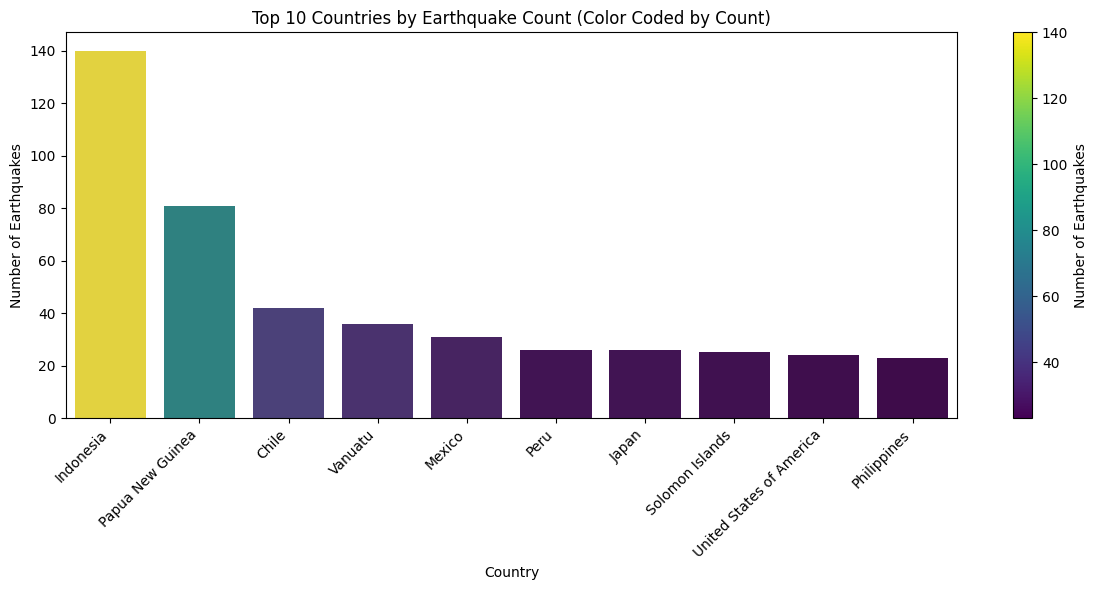

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as colors

# Count the occurrences of each country
country_counts = df['country'].value_counts().nlargest(10)

# Create a colormap and normalize the data for coloring
cmap = cm.viridis
norm = colors.Normalize(vmin=country_counts.min(), vmax=country_counts.max())

# Get colors for each bar based on their count
bar_colors = [cmap(norm(value)) for value in country_counts.values]

fig, ax = plt.subplots(figsize=(12, 6))

# Create the bar plot using the generated colors
sns.barplot(x=country_counts.index, y=country_counts.values, palette=bar_colors, ax=ax)

plt.title('Top 10 Countries by Earthquake Count (Color Coded by Count)')
plt.xlabel('Country')
plt.ylabel('Number of Earthquakes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add a color bar to represent the number of earthquakes
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Dummy array for the scalar mappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Number of Earthquakes')

plt.show()

### Histogram: Distribution of Earthquake Magnitudes

This histogram shows the frequency distribution of earthquake magnitudes. It helps us understand the common range of magnitudes and identify if there are any particular magnitude ranges that occur more frequently.

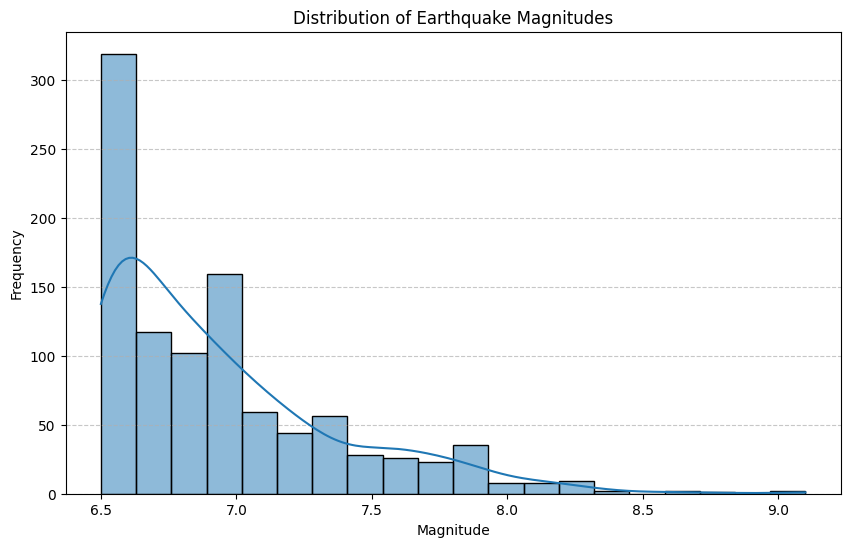

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['magnitude'], bins=20, kde=True)
plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Pie Chart: Proportion of Earthquakes by Top 10 Countries

This pie chart visualizes the contribution of the top 10 most earthquake-prone countries to the total count of earthquakes within this subset. Each slice represents a country, and its size corresponds to the percentage of earthquakes it accounts for.

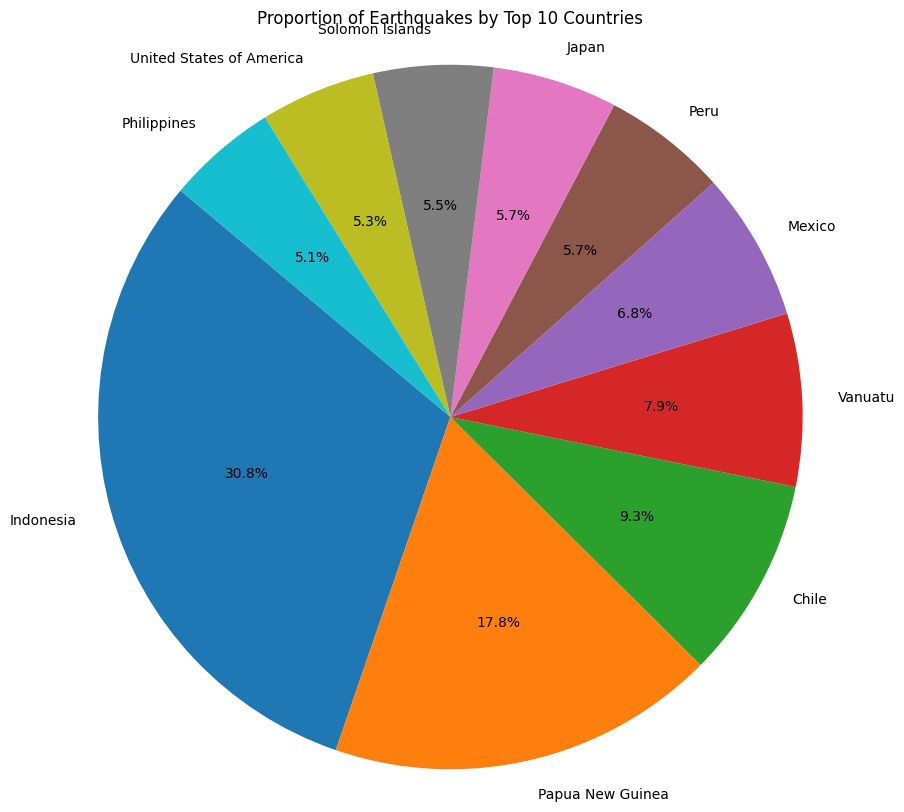

In [ ]:
import matplotlib.pyplot as plt

# Ensure country_counts is defined (from previous bar plot)
# If not, uncomment and run: country_counts = df['country'].value_counts().nlargest(10)

plt.figure(figsize=(10, 10))
plt.pie(
    country_counts.values,
    labels=country_counts.index,
    autopct='%1.1f%%', # Format percentage display
    startangle=140
)
plt.title('Proportion of Earthquakes by Top 10 Countries')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Scatter Plot: Earthquake Magnitude vs. Depth

This scatter plot illustrates the relationship between the magnitude of an earthquake and its depth. It can help us observe if there's any correlation between how strong an earthquake is and how deep it occurs.

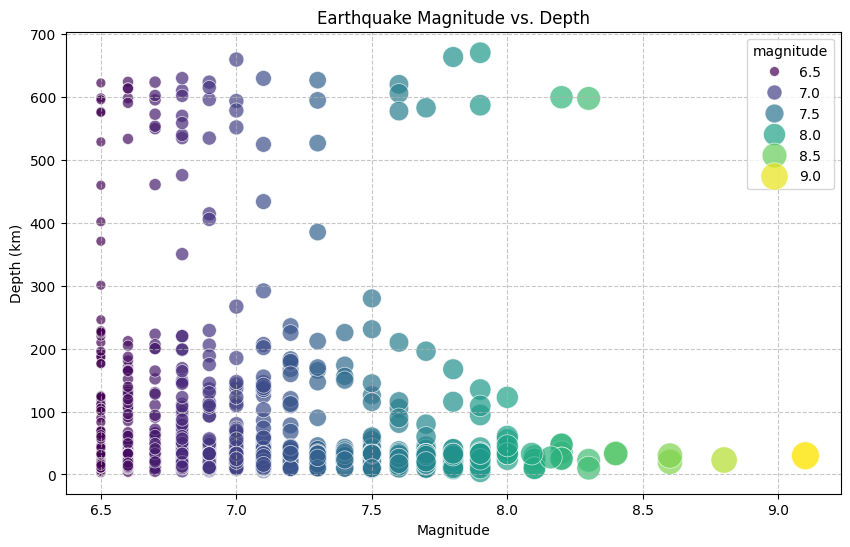

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='magnitude', y='depth', data=df, hue='magnitude', palette='viridis', size='magnitude', sizes=(50, 400), alpha=0.7)
plt.title('Earthquake Magnitude vs. Depth')
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()